In [1]:
import os


os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"


### Choose model for attribution

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
# Choose tokenizer and model

# model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"
# model_name = "Qwen/Qwen2.5-3B"
# model_name = "Qwen/Qwen2.5-1.5B"
model_name = "google/gemma-3-1b-pt"
# model_name = "google/gemma-3-4b-pt"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if device == "cpu":
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

### Select scope type

In [3]:
# mode = 'Temperature'
# mode = 'Semantic'
mode = 'Fisher'

### Set attribution prompt

In [4]:
# string = "Italian: Buon pomeriggio, i miei colleghi ricercatori. English: Good afternoon, my fellow researchers"
# string = "German: Dies ist ein Aufsatz über kausale Zuschreibung. English: This is a paper on causal attribution"
string = "French: Nous l'appelons lentille jacobienne. English: We call it Jacobian Scope"
# string = "Ari braced herself. I need you to take me to Azazil.\n\nGlass gave her a sharp, curious look but unlike Red, he didn't question her. All right. Now?\n\nPlease.\n\nVery well. He looked back at Trey and touched his cheek tenderly. Whatever passed between them caused Trey to glower and he turned to Ari"

### Perform attribution

In [5]:
import JacobianScopes
print(f"JacobianScopes package path: {JacobianScopes.__file__}")

JacobianScopes package path: /home/jl3499/JacobianScopes/JacobianScopes/src/JacobianScopes/__init__.py


In [6]:
scores, logits, decoded_tokens, grad_idx, loss_position = JacobianScopes.run_scope(model, 
                                                                                   tokenizer, 
                                                                                   string, 
                                                                                   mode, 
                                                                                   front_pad=1, 
                                                                                   loss_position=-2, 
                                                                                   device=device)
    

### Visualize prediction

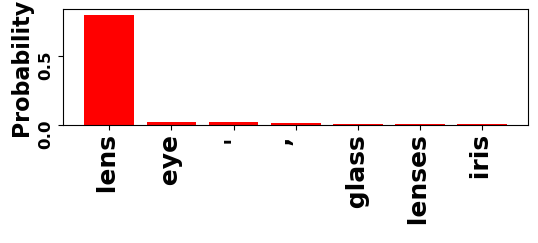

In [7]:

logit_vector = logits[-2].detach()             
# Compute softmax probabilities
probs = torch.softmax(logit_vector, dim=-1)
JacobianScopes.natural_language_pred_plotter(probs, tokenizer, k = 7)

### Visualize attribution

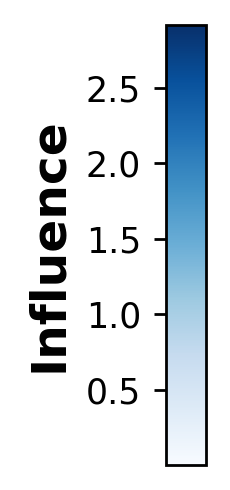

In [8]:

JacobianScopes.natural_language_attribution_plotter(decoded_tokens, grad_idx, scores, mode, loss_position, style = 'B' )